In [1]:
import ast
import os
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

def extract_genus_name(x):
    try:
        genus_dict = ast.literal_eval(x)
        return genus_dict.get('name', None)
    except:
        return None

os.chdir('/active-data/analysis_results/chr_pla')
all_data = pd.read_csv('genome_chr-pla_statistics.csv')
all_data['genus_clean'] = all_data['genus'].apply(extract_genus_name)
counts = all_data['genus_clean'].value_counts()
keep_genus = counts[counts >= 400].index.to_list()
print(keep_genus)

['Escherichia', 'Klebsiella', 'Staphylococcus', 'Pseudomonas', 'Bacillus', 'Salmonella', 'Streptococcus', 'Streptomyces', 'Acinetobacter', 'Enterococcus', 'Bordetella', 'Enterobacter', 'Xanthomonas', 'Campylobacter', 'Vibrio', 'Mycobacterium', 'Corynebacterium', 'Burkholderia', 'Listeria', 'Citrobacter', 'Helicobacter']


In [2]:
def process_replicon_data(fraction_data, label = 'pident_90'):
    typ_chr = fraction_data[fraction_data[f'category-{label}'] == 'typical chromosome']
    min_size = min(typ_chr['size'])
    tra_rep = fraction_data[fraction_data[f'category-{label}'] == 'intermediate replicon']
    if tra_rep.empty:
        return min_size * 0.5
    else:
        tra_max = max(tra_rep['size'])
        return (min_size + tra_max)/2

label = 'pident_90'
all_trasi = []
mob_data = []
amr_data = []
genus_wi = []
genus_data = {}
for genus_name in keep_genus:
    #genus_name = 'Escherichia'
    folder = f'/active-data/analysis_results/chr_pla/genus/statistics_records/{genus_name}'
    contig_info = pd.read_csv(f'{folder}/replicon-plasmid_fraction-self_bitscore_statistics.csv')
    target_dir = rf"/active-data/analysis_results/chr_pla/genus/IMG_PR_plasmid/{genus_name}"
    contig_data = pd.read_csv(f'{target_dir}/IMGPR_plasmid_data.tsv', sep='\t')
    
    plas_data = pd.read_csv(f'{target_dir}/IMGPR_plasmid_plasmidness.tsv', sep='\t')
    plas_data = plas_data.rename(columns={'contig': 'plasmid_id'})
    merged_data = pd.merge(contig_data, plas_data, on='plasmid_id', how='left')
    merged_data = merged_data[(merged_data['source_type']=='Metagenome')]# & (merged_data['putatively_complete']=='Yes')]

    size_split = process_replicon_data(contig_info, label)
    filted_data = merged_data[(merged_data['size'] < size_split) & (merged_data['average plasmid fraction-pident_90'] < 0.3)].copy()
    if filted_data.empty:
        continue
    else:
        mob_table = pd.read_csv(f'{target_dir}/annotations/IMGPR_metagenome_plasmid_mobtyper_results.tsv', sep='\t', index_col=0)
        mob_table['plasmid_id'] = mob_table['id'].str.split('|').str[0]
        mob_data.append(mob_table)
        
        amr_table = pd.read_csv(f'{target_dir}/annotations/IMGPR_metagenome_plasmid_AMRtyper_results.tsv', sep='\t', index_col=0)
        amr_data.append(amr_table)
        
        filted_data['genus']=genus_name
        all_trasi.append(filted_data)
        genus_wi.append(genus_name)
        genus_data[genus_name] = merged_data

mob_data = pd.concat(mob_data, ignore_index=True)
#mob_data = mob_data.drop_duplicates(subset=["plasmid_id"], keep="first")
amr_data = pd.concat(amr_data, ignore_index=True)
amr_data = amr_data.drop_duplicates(subset=["plasmid_id"], keep="first")
all_trasi_pla = pd.concat(all_trasi, ignore_index=True)

all_trasi_pla = pd.merge(all_trasi_pla, mob_data[['plasmid_id', 'predicted_mobility']], on='plasmid_id', how='left')
all_trasi_pla = pd.merge(all_trasi_pla, amr_data, on='plasmid_id', how='left')

In [3]:
#ecosystem
def process_single_ecos(path):
    if pd.isna(path) or not isinstance(path, str):
        return "Others", "Other unknown", "#e6d9f0"
    
    parts = path.split(";")
    level1 = parts[0]
    
    def classify_eng(path):
        parts = path.split(";")
        if len(parts) < 2:
            return "Others"
        sec = parts[1]
        if sec.startswith("Bioreactor"):
            return "Bioreactor"
        elif sec.startswith("Built environment"):
            return "Built environment"
        elif sec.startswith("Wastewater"):
            return "Wastewater"
        else:
            return "Others"

    def classify_env(path):
        parts = path.split(";")
        if len(parts) < 2:
            return "Others"
        sec = parts[1]
        if sec == "Aquatic":
            return "Aquatic"
        elif sec == "Terrestrial":
            return "Terrestrial"
        else:
            return "Others"

    def classify_host(path):
        parts = path.split(";")
        if len(parts) < 2:
            return "Others"
        sec = parts[1]
        if sec == "Mammals: Human":
            return "Mammals: Human"
        elif sec == "Mammals":
            return "Mammals"
        elif sec == "Plants":
            return "Plants"
        else:
            return "Others"

    if level1 == "Mixed, Engineered":
        group_l1 = "Others"
        subcat = "Mixed, Engineered"
    elif level1 == "Engineered":
        group_l1 = "Engineered"
        subcat = classify_eng(path)
    elif level1 == "Environmental":
        group_l1 = "Environmental"
        subcat = classify_env(path)
    elif level1 == "Host-associated":
        group_l1 = "Host-associated"
        subcat = classify_host(path)
    else:
        group_l1 = "Others"
        subcat = "Other unknown"
    
    sub_palette = {
        "Engineered": {
            "Bioreactor": "#08519c",
            "Built environment": "#3182bd",
            "Wastewater": "#6baed6",
            "Others": "#bdd7e7"
        },
        "Environmental": {
            "Aquatic": "#238b45",
            "Terrestrial": "#41ab5d"
        },
        "Host-associated": {
            "Mammals: Human": "#e6550d",
            "Mammals": "#fd8d3c",
            "Plants": "#fdae6b",
            "Others": "#fee0d2"
        },
        "Others": {
            "Mixed, Engineered": "#9467bd",
            "Other unknown": "#e6d9f0"
        }
    }
    
    color = sub_palette.get(group_l1, {}).get(subcat, "#e6d9f0")
    return group_l1, subcat, color


all_trasi_pla_processed = all_trasi_pla.copy(deep=True)

all_trasi_pla_processed[["ecosystem_category", "ecosystem_subcat", "ecosystem_color"]] = (
    all_trasi_pla_processed["ecosystem"].apply(lambda x: pd.Series(process_single_ecos(x)))
)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

df = all_trasi_pla_processed.copy()
df["eco_full_label"] = df["ecosystem_category"]+' '+"|"+' '+df["ecosystem_subcat"]
sub_palette = {"Engineered":{"Bioreactor":"#08519c","Built environment":"#3182bd","Wastewater":"#6baed6","Others":"#bdd7e7"},
               "Environmental":{"Aquatic":"#238b45","Terrestrial":"#41ab5d"},
               "Host-associated":{"Mammals: Human":"#e6550d","Mammals":"#fd8d3c","Plants":"#fdae6b","Others":"#fee0d2"},
               "Others":{"Mixed, Engineered":"#9467bd","Other unknown":"#e6d9f0"}}
eco_order = []
for l1,subdict in sub_palette.items():
    for l2 in subdict.keys():eco_order.append(f"{l1} | {l2}")
set1 = plt.cm.Set1.colors
mobility_order = ["conjugative","mobilizable","non-mobilizable"]
mobility_map = {'conjugative':set1[1],'mobilizable':set1[2],'non-mobilizable':set1[0]}
amr_order = ["AMR","non-AMR"]
amr_map = {'AMR':set1[-2],'non-AMR':set1[-1]}

flow_gen_eco = df.groupby(["genus","eco_full_label"]).size().reset_index(name="flow1")
flow_eco_mob = df.groupby(["genus","eco_full_label","predicted_mobility"]).size().reset_index(name="flow2")
flow_mob_amr = df.groupby(["genus","eco_full_label","predicted_mobility","AMR_type"]).size().reset_index(name="flow3")

eco_sub = df[["eco_full_label","ecosystem_color"]].drop_duplicates()
eco_color_map = dict(zip(eco_sub["eco_full_label"],eco_sub["ecosystem_color"]))

In [5]:
# human_system
human_system_order_priority = [
    "Digestive system",
    "Respiratory system",
    "Lymphatic system",
    "Integumentary system"
]
human_temp_data = all_trasi_pla_processed[
    all_trasi_pla_processed['ecosystem'].str.contains('Host-associated;Mammals: Human', na=False)
].copy()

def combine_seg3_seg4_only(s):
    if pd.isna(s):
        return None
    parts = [p.strip() for p in str(s).split(";")]
    seg3 = parts[2] if len(parts) >= 3 else ""
    seg4 = parts[3] if len(parts) >= 4 else ""
    if seg3 and seg4:
        return f"{seg3} | {seg4}"
    elif seg3:
        return seg3
    else:
        return None

human_temp_data["eco_3_4"] = human_temp_data["ecosystem"].apply(combine_seg3_seg4_only)

human_body_site_color_map = {
    "Digestive system | Oral cavity": "#e6550d",
    "Digestive system | Large intestine": "#fd8d3c",
    "Digestive system | Pharynx/Throat": "#fdae6b",
    "Digestive system | Biliary tract": "#fdd0a2",
    "Respiratory system | Pharynx/Throat": "#3182bd",
    "Lymphatic system | Tonsils": "#31a354",
    "Integumentary system | Skin": "#756bb1"
}
def get_human_eco34_color(name):
    return human_body_site_color_map.get(name, "#636363")

def human_first_upper(s: str):
    return s[0].upper() + s[1:] if s else s

human_flow_gen_eco = human_temp_data.groupby(["genus","eco_3_4"]).size().reset_index(name="flow1")
human_flow_eco_mob = human_temp_data.groupby(["genus","eco_3_4","predicted_mobility"]).size().reset_index(name="flow2")
human_flow_mob_amr = human_temp_data.groupby(["genus","eco_3_4","predicted_mobility","AMR_type"]).size().reset_index(name="flow3")

human_genus_total = human_flow_gen_eco.groupby("genus")["flow1"].sum()
human_eco34_total_df = human_flow_gen_eco.groupby("eco_3_4")["flow1"].sum().reset_index()
human_mob_total = human_flow_eco_mob.groupby("predicted_mobility")["flow2"].sum()
human_amr_total = human_flow_mob_amr.groupby("AMR_type")["flow3"].sum()

human_exist_genus = set(human_flow_gen_eco["genus"].unique())
human_genus_order = [g for g in genus_wi if g in human_exist_genus]

human_eco34_total_df["system"] = human_eco34_total_df["eco_3_4"].str.split(" \\| ").str[0]
human_sys_rank = {sys:i for i,sys in enumerate(human_system_order_priority)}
human_eco34_total_df["sys_rank"] = human_eco34_total_df["system"].map(human_sys_rank).fillna(999)
human_eco34_total_df = human_eco34_total_df.sort_values(by=["sys_rank", "flow1"], ascending=[True, False])
human_eco34_order = human_eco34_total_df["eco_3_4"].tolist()

human_mob_order = sorted(human_temp_data["predicted_mobility"].unique())
human_amr_order = sorted(human_temp_data["AMR_type"].unique())

In [6]:
import matplotlib.path as mpath
import matplotlib.patches as mpatches
Path = mpath.Path

def sankey_band(ax,x0,y0_low,y0_high,x1,y1_low,y1_high,color,alpha=0.7):
    dist = abs(x1 - x0)
    ctrl_scale = 0.45
    c0_x = x0 + dist * ctrl_scale
    c1_x = x1 - dist * ctrl_scale
    verts = [(x0,y0_high),(c0_x,y0_high),(c1_x,y1_high),(x1,y1_high),(x1,y1_low),(c1_x,y1_low),(c0_x,y0_low),(x0,y0_low),(x0,y0_high)]
    codes = [Path.MOVETO,Path.CURVE4,Path.CURVE4,Path.LINETO,Path.LINETO,Path.CURVE4,Path.CURVE4,Path.LINETO,Path.CLOSEPOLY]
    path = Path(verts,codes)
    patch = mpatches.PathPatch(path,facecolor=color,edgecolor="none",alpha=alpha)
    ax.add_patch(patch)

class MatplotlibNativeSankey:
    def __init__(self,ax,node_width=0.3,vertical_gap=0.12,draw_label=True):
        self.ax = ax
        self.node_width = node_width
        self.vgap = vertical_gap
        self.draw_label = draw_label
        self.layers = dict()
        self.out_ptr = dict()
        self.in_ptr = dict()
        
    def register_layer(self,x_pos,node_list):
        total_flow = sum(item[1] for item in node_list)
        y_cursor = total_flow / 2.0
        nodes_data = []
        out_top = dict()
        in_top = dict()
        for item in node_list:
            name,flow = item[0],item[1]
            if len(item)>=5:fc,ec,lw = item[2],item[3],item[4]
            else:fc,ec,lw = "#dddddd","#222222",0.5
            y_top = y_cursor
            y_bot = y_cursor - flow
            nodes_data.append((name,flow,y_bot,y_top,fc,ec,lw))
            out_top[name] = y_top
            in_top[name] = y_top
            y_cursor = y_bot - self.vgap
        self.layers[x_pos] = nodes_data
        self.out_ptr[x_pos] = out_top
        self.in_ptr[x_pos] = in_top
        return nodes_data
        
    def draw_node_rects(self):
        for x,nodes in self.layers.items():
            for name,flow,y_bot,y_top,fc,ec,lw in nodes:
                rect = mpatches.Rectangle((x,y_bot),self.node_width,flow,ec=ec,lw=lw,fc=fc)
                self.ax.add_patch(rect)
                if self.draw_label:self.ax.text(x-0.06,(y_bot+y_top)/2,name,va="center",ha="right")
                    
    def connect(self,x_from,src_name,x_to,dst_name,flow_val,color="#73a9c2",alpha=0.65):
        src_bot,src_top = None,None
        for name,f,yb,yt,_,_,_ in self.layers[x_from]:
            if name == src_name:src_bot,src_top = yb,yt;break
        dst_bot,dst_top = None,None
        for name,f,yb,yt,_,_,_ in self.layers[x_to]:
            if name == dst_name:dst_bot,dst_top = yb,yt;break
        current_src_top = self.out_ptr[x_from][src_name]
        seg0_high,seg0_low = current_src_top,current_src_top-flow_val
        self.out_ptr[x_from][src_name] = seg0_low
        current_dst_top = self.in_ptr[x_to][dst_name]
        seg1_high,seg1_low = current_dst_top,current_dst_top-flow_val
        self.in_ptr[x_to][dst_name] = seg1_low
        out_x = x_from+self.node_width;in_x = x_to
        sankey_band(self.ax,out_x,seg0_low,seg0_high,in_x,seg1_low,seg1_high,color=color,alpha=alpha)

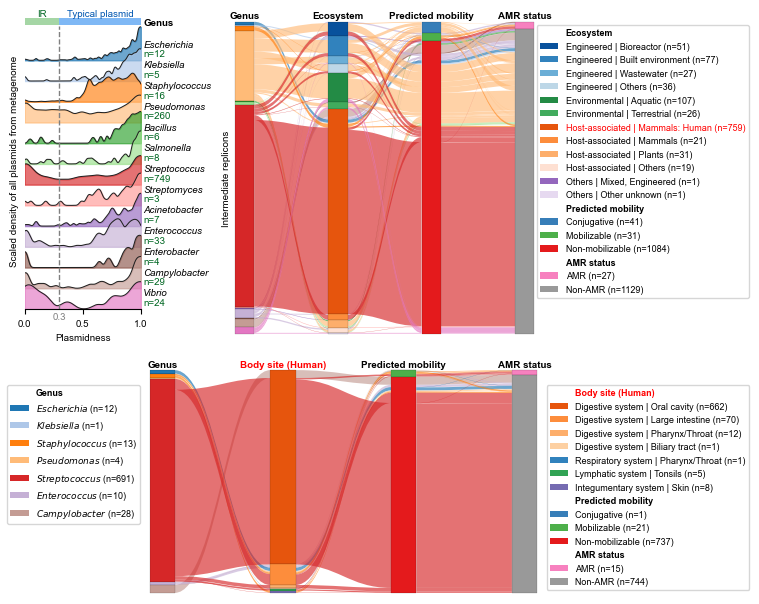

In [7]:
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
from matplotlib.patches import Patch
from matplotlib.patches import Rectangle
from matplotlib.patches import ConnectionPatch

plt.rcParams["font.family"] = "Arial"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})
target_col = "average plasmid fraction-pident_90"
x_lim_min, x_lim_max = 0, 1
x_grid = np.linspace(x_lim_min, x_lim_max, 500)

overlap = 0.7
height = 0.9
bw = 0.1
scale_factor = 0.5

tab20_raw = plt.cm.tab20.colors
n_groups = len(genus_wi)

genus_color_dict = {}
for idx, gname in enumerate(genus_wi):
    genus_color_dict[gname] = tab20_raw[idx % len(tab20_raw)]

fig = plt.figure(figsize=(7.5, 7.5))
ax_ridgeline = fig.add_axes([0.03, 0.6, 0.155, 0.395])

vertical_shift = 0
for idx, key in enumerate(genus_wi):
    df = genus_data[key]
    vals = df[target_col].dropna()
    val_num = len(df[df[target_col] < 0.3])
    fill_color = genus_color_dict[key]
    kde = gaussian_kde(vals, bw_method=bw)
    y_kde = kde(x_grid)
    y_kde_s = y_kde/(y_kde+1)
    y_scaled = y_kde_s * scale_factor + vertical_shift

    ax_ridgeline.plot(x_grid, y_scaled, color="#222222", lw=0.75)
    ax_ridgeline.fill_between(x_grid, vertical_shift, y_scaled, color=fill_color, alpha=0.65)

    ax_ridgeline.text(1.02, vertical_shift + scale_factor/3, key, va="bottom", ha="left", fontstyle='italic')
    ax_ridgeline.text(1.02, vertical_shift + scale_factor/3-0.01, f"n={val_num}", va="top", ha="left", color='#006622')
    vertical_shift -= (1 - overlap)

ax_ridgeline.text(1.02, 1 - overlap + scale_factor/2, "Genus", va="center", ha="left", weight="bold")
ax_ridgeline.set_xlim(x_lim_min, x_lim_max)
ax_ridgeline.set_xlabel("Plasmidness")
ax_ridgeline.set_ylabel("Scaled density of all plasmids from metagenome")
ax_ridgeline.set_ylim(bottom=vertical_shift+(1 - overlap))
ax_ridgeline.set_yticks([])
ax_ridgeline.add_patch(Rectangle((0, 0.51), 0.3, 0.1, facecolor='#a5d6a5', edgecolor=None))
ax_ridgeline.add_patch(Rectangle((0.3, 0.51), 0.7, 0.1, facecolor='#7fb8f5', edgecolor=None))
ax_ridgeline.text((0+0.3)/2, 0.51+0.1, 'IR', ha='center', va='bottom', c='#006622')
ax_ridgeline.text((1+0.3)/2, 0.51+0.1, 'Typical plasmid', ha='center', va='bottom', c='#0056b0')
ax_ridgeline.vlines(0.3, ymin=vertical_shift+(1 - overlap), ymax=0.5, color="gray", lw=1, linestyle="--")
ax_ridgeline.text(0.3, vertical_shift+(1 - overlap)-0.05, '0.3', ha='center', va='top', c="gray")
ax_ridgeline.spines["top"].set_visible(False)
ax_ridgeline.spines["right"].set_visible(False)
ax_ridgeline.spines["left"].set_visible(False)

ax_sankey = fig.add_axes([0.305, 0.565, 0.41, 0.42])
ax_sankey.axis("off")
sk = MatplotlibNativeSankey(ax_sankey,node_width=0.5,vertical_gap=0,draw_label=False)
x_gen,x_eco,x_mob,x_amr = 0.8,3.2,5.6,8.0

def first_upper(s: str) -> str:
    if not s:
        return s
    return s[0].upper() + s[1:]

gen_node_def = []
gen_legend_elements = []
for g in genus_wi:
    total = flow_gen_eco.loc[flow_gen_eco["genus"]==g,"flow1"].sum()
    fc = genus_color_dict[g]
    gen_node_def.append((g,total,fc,"#111111",0.1))
    gen_legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=g))
sk.register_layer(x_gen,gen_node_def)

eco_node_def = []
eco_legend_elements = []
for name in eco_order:
    total = flow_gen_eco.loc[flow_gen_eco["eco_full_label"]==name,"flow1"].sum()
    fc = eco_color_map.get(name,"#cccccc")
    eco_node_def.append((name,total,fc,"#111111",0.1))
    eco_legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=f"{name} (n={total})"))
sk.register_layer(x_eco,eco_node_def)

mob_node_def = []
mob_legend_elements = []
for name in mobility_order:
    total = flow_eco_mob.loc[flow_eco_mob["predicted_mobility"]==name,"flow2"].sum()
    fc = mobility_map[name]
    mob_node_def.append((name,total,fc,"#111111",0.1))
    mob_legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=f"{first_upper(name)} (n={total})"))
sk.register_layer(x_mob,mob_node_def)

amr_node_def = []
amr_legend_elements = []
for name in amr_order:
    total = flow_mob_amr.loc[flow_mob_amr["AMR_type"]==name,"flow3"].sum()
    fc = amr_map[name]
    amr_node_def.append((name,total,fc,"#111111",0.1))
    amr_legend_elements.append(plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=f"{first_upper(name)} (n={total})"))
sk.register_layer(x_amr,amr_node_def)

def get_layer_y_extent(nodes_list,gap):
    total_flow = sum(item[1] for item in nodes_list)
    node_count = len(nodes_list)
    total_gap = gap*(node_count-1)
    half_height = (total_flow+total_gap)/2
    return -half_height,half_height
y1_min,y1_max = get_layer_y_extent(gen_node_def,sk.vgap)
y2_min,y2_max = get_layer_y_extent(eco_node_def,sk.vgap)
y3_min,y3_max = get_layer_y_extent(mob_node_def,sk.vgap)
y4_min,y4_max = get_layer_y_extent(amr_node_def,sk.vgap)
all_min = min(y1_min,y2_min,y3_min,y4_min)
all_max = max(y1_max,y2_max,y3_max,y4_max)
margin = 1.01
final_ymin = all_min*margin
final_ymax = all_max*margin
ax_sankey.set_xlim(0.7,8.6)
ax_sankey.set_ylim(final_ymin,final_ymax)
title_y = final_ymax
ax_sankey.text(0.7,0,"Intermediate replicons",ha="right",va="center",rotation=90)
ax_sankey.text(x_gen+sk.node_width/2,title_y,"Genus",ha="center",va="bottom",weight="bold")
ax_sankey.text(x_eco+sk.node_width/2,title_y,"Ecosystem",ha="center",va="bottom",weight="bold")
ax_sankey.text(x_mob+sk.node_width/2,title_y,"Predicted mobility",ha="center",va="bottom",weight="bold")
ax_sankey.text(x_amr+sk.node_width/2,title_y,"AMR status",ha="center",va="bottom",weight="bold")

# Genus → Ecosystem
for _,row in flow_gen_eco.iterrows():
    s,t,val = row["genus"],row["eco_full_label"],row["flow1"]
    c = genus_color_dict.get(s,"#888888")
    sk.connect(x_gen,s,x_eco,t,val,color=c,alpha=0.65)

# Ecosystem → Predicted Mobility
for _,row in flow_eco_mob.iterrows():
    g,s,t,val = row["genus"],row["eco_full_label"],row["predicted_mobility"],row["flow2"]
    c = genus_color_dict.get(g,"#888888")
    sk.connect(x_eco,s,x_mob,t,val,color=c,alpha=0.65)

# Predicted Mobility → AMR_type
for _,row in flow_mob_amr.iterrows():
    g,s,t,val = row["genus"],row["predicted_mobility"],row["AMR_type"],row["flow3"]
    c = genus_color_dict.get(g,"#888888")
    sk.connect(x_mob,s,x_amr,t,val,color=c,alpha=0.65)

sk.draw_node_rects()

def make_group_title(text):
    return Patch(color="none", label=text)


all_handles = [
    make_group_title("Ecosystem"),
    *eco_legend_elements,
    make_group_title("Predicted mobility"),
    *mob_legend_elements,
    make_group_title("AMR status"),
    *amr_legend_elements
]

group_title_indices = [0, 1 + len(eco_legend_elements), 1 + len(eco_legend_elements) + 1 + len(mob_legend_elements)]

leg = ax_sankey.legend(handles=all_handles, loc="upper left", bbox_to_anchor=(0.98, 1), ncol=1)

text_list = leg.get_texts()
for idx in group_title_indices:
    if idx < len(text_list):
        text_list[idx].set_weight("bold")

for t in text_list:
    if 'Human' in t.get_text():
        t.set_color('red')

human_ax = fig.add_axes([0.19, 0.22, 0.53, 0.3])
human_ax.axis("off")

human_sk = MatplotlibNativeSankey(human_ax, node_width=0.5, vertical_gap=0, draw_label=False)
human_x_gen, human_x_eco34, human_x_mob, human_x_amr = 0.8, 3.2, 5.6, 8.0

# Genus
human_gen_node_def = []
for g in human_genus_order:
    total = human_genus_total[g]
    fc = genus_color_dict[g]
    human_gen_node_def.append((g, total, fc, "#111111", 0.1))
human_sk.register_layer(human_x_gen, human_gen_node_def)

# Body site
human_eco34_node_def = []
human_eco34_legend_elements = []
for name in human_eco34_order:
    total = human_eco34_total_df.loc[human_eco34_total_df["eco_3_4"]==name, "flow1"].iloc[0]
    fc = get_human_eco34_color(name)
    human_eco34_node_def.append((name, total, fc, "#111111", 0.1))
    human_eco34_legend_elements.append(
        plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=f"{name} (n={total})")
    )
human_sk.register_layer(human_x_eco34, human_eco34_node_def)

# Mobility
human_mob_node_def = []
human_mob_legend_elements = []
for name in human_mob_order:
    total = human_mob_total[name]
    fc = mobility_map[name]
    human_mob_node_def.append((name, total, fc, "#111111", 0.1))
    human_mob_legend_elements.append(
        plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=f"{human_first_upper(name)} (n={total})")
    )
human_sk.register_layer(human_x_mob, human_mob_node_def)

# AMR
human_amr_node_def = []
human_amr_legend_elements = []
for name in human_amr_order:
    total = human_amr_total[name]
    fc = amr_map[name]
    human_amr_node_def.append((name, total, fc, "#111111", 0.1))
    human_amr_legend_elements.append(
        plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=f"{human_first_upper(name)} (n={total})")
    )
human_sk.register_layer(human_x_amr, human_amr_node_def)

def get_human_layer_y_extent(nodes_list,gap):
    total_flow = sum(item[1] for item in nodes_list)
    node_count = len(nodes_list)
    total_gap = gap*(node_count-1)
    half_height = (total_flow+total_gap)/2
    return -half_height,half_height

human_y1_min,human_y1_max = get_human_layer_y_extent(human_gen_node_def, human_sk.vgap)
human_y2_min,human_y2_max = get_human_layer_y_extent(human_eco34_node_def, human_sk.vgap)
human_y3_min,human_y3_max = get_human_layer_y_extent(human_mob_node_def, human_sk.vgap)
human_y4_min,human_y4_max = get_human_layer_y_extent(human_amr_node_def, human_sk.vgap)
human_all_min = min(human_y1_min,human_y2_min,human_y3_min,human_y4_min)
human_all_max = max(human_y1_max,human_y2_max,human_y3_max,human_y4_max)
human_margin = 1.01
human_final_ymin = human_all_min * human_margin
human_final_ymax = human_all_max * human_margin

human_ax.set_xlim(0.7, 8.6)
human_ax.set_ylim(human_final_ymin, human_final_ymax)
human_title_y = human_final_ymax

human_ax.text(human_x_gen+human_sk.node_width/2, human_title_y, "Genus", ha="center", va="bottom", weight="bold")
human_ax.text(human_x_eco34+human_sk.node_width/2, human_title_y, "Body site (Human)", ha="center", va="bottom", weight="bold", color='red')
human_ax.text(human_x_mob+human_sk.node_width/2, human_title_y, "Predicted mobility", ha="center", va="bottom", weight="bold")
human_ax.text(human_x_amr+human_sk.node_width/2, human_title_y, "AMR status", ha="center", va="bottom", weight="bold")

# genus → eco
for _,row in human_flow_gen_eco.iterrows():
    gn,eco34,val = row["genus"], row["eco_3_4"], row["flow1"]
    c = genus_color_dict.get(gn, "#888888")
    human_sk.connect(human_x_gen, gn, human_x_eco34, eco34, val, color=c, alpha=0.65)

# eco → mobility
for _,row in human_flow_eco_mob.iterrows():
    gn,eco34,mob,val = row["genus"], row["eco_3_4"], row["predicted_mobility"], row["flow2"]
    c = genus_color_dict.get(gn, "#888888")
    human_sk.connect(human_x_eco34, eco34, human_x_mob, mob, val, color=c, alpha=0.65)

# mobility → amr
for _,row in human_flow_mob_amr.iterrows():
    gn,eco34,mob,amr,val = row["genus"], row["eco_3_4"], row["predicted_mobility"], row["AMR_type"], row["flow3"]
    c = genus_color_dict.get(gn, "#888888")
    human_sk.connect(human_x_mob, mob, human_x_amr, amr, val, color=c, alpha=0.65)

human_sk.draw_node_rects()

def make_human_group_title(text):
    return Patch(color="none", label=text)

human_genus_legend_elements = []
for g in human_genus_order:
    n_val = human_genus_total[g]
    fc = genus_color_dict[g]
    lbl = r"$\mathit{" + g + r"}$ (n=" + str(n_val) + r")"
    human_genus_legend_elements.append(
        plt.Rectangle((0,0),1,1, facecolor=fc, edgecolor="#111111", lw=0, label=lbl)
    )

human_genus_handles = [make_human_group_title("Genus"), *human_genus_legend_elements]
human_leg_genus = human_ax.legend(handles=human_genus_handles, loc="upper right", bbox_to_anchor=(0, 0.95), ncol=1,)
human_gen_texts = human_leg_genus.get_texts()
if len(human_gen_texts) > 0:
    human_gen_texts[0].set_weight("bold")
human_ax.add_artist(human_leg_genus)

human_other_handles = [
    make_human_group_title("Body site (Human)"),
    *human_eco34_legend_elements,
    make_human_group_title("Predicted mobility"),
    *human_mob_legend_elements,
    make_human_group_title("AMR status"),
    *human_amr_legend_elements
]

human_leg_other = human_ax.legend(handles=human_other_handles, loc="upper left", bbox_to_anchor=(1, 0.95), ncol=1,)

human_other_texts = human_leg_other.get_texts()
human_other_title_pos = [0, 1+len(human_eco34_legend_elements), 1+len(human_eco34_legend_elements)+1+len(human_mob_legend_elements)]
for pos in human_other_title_pos:
    if pos < len(human_other_texts):
        human_other_texts[pos].set_weight("bold")

for t in human_other_texts:
    if 'Human' in t.get_text():
        t.set_color('red')


#con = ConnectionPatch((0.97,0.85), (0.88,0.5), coordsA=fig.transFigure, coordsB=fig.transFigure, 
#                      arrowstyle='->', shrinkA=8, shrinkB=3, mutation_scale=12, lw=1.2, linestyle='--', color='red', zorder=10)
#fig.add_artist(con)

rect = plt.Rectangle((0, 0), 1, 1, transform=fig.transFigure, facecolor='none', edgecolor='black', linewidth=2)
#fig.patches.append(rect)

base_folder = '/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig(f"IMG_PR_intermediate_replicon_result.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"IMG_PR_intermediate_replicon_result.png", dpi=1000, bbox_inches="tight", transparent=True)
plt.show()